In [1]:
from pathlib import Path
OUTPUT_DIR = Path('/Users/fteodoro/Dropbox/Doutorado/Tese/figuras')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pywt

plt.rcParams.update({'font.family': 'serif', 'font.size': 11})

Saved: /Users/fteodoro/Dropbox/Doutorado/Tese/figuras/fig_wavelet_freq_response.pdf


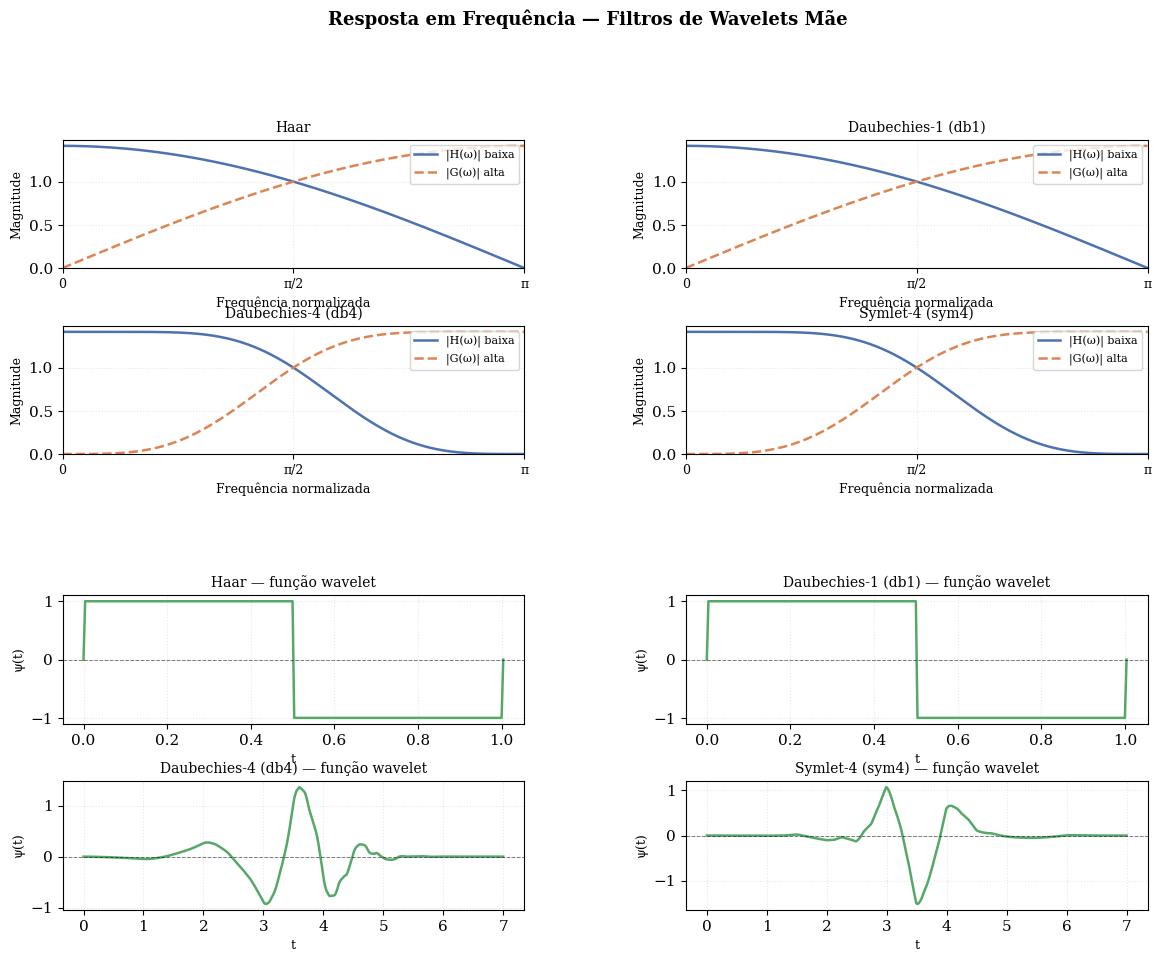

In [3]:
WAVELETS = ['haar', 'db1', 'db4', 'sym4']
LABELS   = ['Haar', 'Daubechies-1 (db1)', 'Daubechies-4 (db4)', 'Symlet-4 (sym4)']

N_FFT = 512

def freq_response(h):
    """Return normalized angular frequency [0, pi] and magnitude of FFT."""
    H = np.fft.rfft(h, n=N_FFT)
    freq = np.linspace(0, np.pi, len(H))
    return freq, np.abs(H)

def highpass_from_lowpass(h):
    """QMF conjugate mirror filter: g[n] = (-1)^n h[L-1-n]."""
    h = np.array(h)
    L = len(h)
    g = np.array([(-1)**n * h[L - 1 - n] for n in range(L)])
    return g

# Build figure: 4 frequency-response panels (2x2) + 4 wavelet-shape panels (2x2)
fig = plt.figure(figsize=(14, 10))
fig.suptitle('Resposta em Frequência — Filtros de Wavelets Mãe',
             fontsize=13, fontweight='bold', y=1.01)

# Grid: 2 rows of sub-figures — top = freq response, bottom = wavelet shape
outer = fig.add_gridspec(2, 1, hspace=0.45)
top_gs  = outer[0].subgridspec(2, 2, hspace=0.45, wspace=0.35)
bot_gs  = outer[1].subgridspec(2, 2, hspace=0.45, wspace=0.35)

for idx, (wname, wlabel) in enumerate(zip(WAVELETS, LABELS)):
    row, col = divmod(idx, 2)

    # --- Frequency response ---
    ax_f = fig.add_subplot(top_gs[row, col])

    wav = pywt.Wavelet(wname)
    h   = np.array(wav.dec_lo)   # low-pass
    g   = highpass_from_lowpass(h)  # high-pass

    freq, H_mag = freq_response(h)
    _,    G_mag = freq_response(g)

    ax_f.plot(freq, H_mag, color='#4C72B0', lw=1.8, label='|H(ω)| baixa')
    ax_f.plot(freq, G_mag, color='#DD8452', lw=1.8, label='|G(ω)| alta', ls='--')
    ax_f.set_xlim(0, np.pi)
    ax_f.set_xticks([0, np.pi/2, np.pi])
    ax_f.set_xticklabels(['0', 'π/2', 'π'], fontsize=9)
    ax_f.set_xlabel('Frequência normalizada', fontsize=9)
    ax_f.set_ylabel('Magnitude', fontsize=9)
    ax_f.set_title(wlabel, fontsize=10)
    ax_f.legend(fontsize=8, loc='upper right')
    ax_f.grid(alpha=0.3, ls=':')
    ax_f.set_ylim(bottom=0)

    # --- Wavelet shape ---
    ax_w = fig.add_subplot(bot_gs[row, col])

    try:
        funcs, x_vals = wav.wavefun(level=8)[:2]
        # wavefun returns (phi, psi, x) for orthogonal wavelets
        # For biorthogonal: (phi_d, psi_d, phi_r, psi_r, x)
        # We want the mother wavelet (psi)
        result = wav.wavefun(level=8)
        if len(result) == 3:
            phi, psi, x = result
        else:
            phi, psi, phi_r, psi_r, x = result
    except Exception:
        psi = np.zeros(100)
        x   = np.linspace(0, 1, 100)

    ax_w.plot(x, psi, color='#55A868', lw=1.8)
    ax_w.axhline(0, color='black', lw=0.7, ls='--', alpha=0.5)
    ax_w.set_xlabel('t', fontsize=9)
    ax_w.set_ylabel('ψ(t)', fontsize=9)
    ax_w.set_title(f'{wlabel} — função wavelet', fontsize=10)
    ax_w.grid(alpha=0.3, ls=':')

out_path = OUTPUT_DIR / 'fig_wavelet_freq_response.pdf'
fig.savefig(out_path, dpi=150, bbox_inches='tight')
print(f'Saved: {out_path}')
plt.show()